In [3]:
# Loading and Inspecting data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')

FIGURES = Path('../outputs/figures')
MODELS = Path('../outputs/models')

In [5]:
df = pd.read_csv('../data/GlobalWeatherRepository.csv')

print('Shape:', df.shape)
df.head()

Shape: (143068, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [6]:
print(df.columns.tolist())

['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 143068 entries, 0 to 143067
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       143068 non-null  str    
 1   location_name                 143068 non-null  str    
 2   latitude                      143068 non-null  float64
 3   longitude                     143068 non-null  float64
 4   timezone                      143068 non-null  str    
 5   last_updated_epoch            143068 non-null  int64  
 6   last_updated                  143068 non-null  str    
 7   temperature_celsius           143068 non-null  float64
 8   temperature_fahrenheit        143068 non-null  float64
 9   condition_text                143068 non-null  str    
 10  wind_mph                      143068 non-null  float64
 11  wind_kph                      143068 non-null  float64
 12  wind_degree                   143068 non-null  int64  


In [8]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,143068.000000,143068.000000,1.430680e+05,143068.000000,143068.00000,143068.000000,143068.000000,143068.000000,143068.000000,143068.000000,...,143068.000000,143068.000000,143068.000000,143068.000000,143068.000000,143068.000000,143068.000000,143068.000000,143068.000000,143068.000000
mean,19.219094,21.931838,1.747689e+09,21.242098,70.23756,7.982751,12.850712,168.972803,1014.038863,29.943971,...,18.183565,449.800854,57.568751,14.810307,10.115855,23.846773,47.765517,1.686457,2.576453,49.549571
std,24.411904,65.781895,1.837893e+07,9.627255,17.32894,7.115657,11.448221,103.667022,10.174744,0.300405,...,13.673186,743.317301,30.416049,23.323288,34.771838,36.264711,147.436296,0.933804,2.423330,35.064970
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.60000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731833e+09,15.600000,60.00000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,195.300000,38.000000,1.789000,1.110000,7.030000,9.805000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747732e+09,23.700000,74.60000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,286.850000,55.000000,5.735000,2.405000,13.875000,19.610000,1.000000,2.000000,49.000000
75%,40.400000,49.882200,1.763536e+09,27.900000,82.30000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,451.400000,73.000000,17.020000,8.100000,27.380000,40.885000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.779518e+09,79.300000,174.70000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'count': missing, '%': missing_pct})
print(missing_df[missing_df['count'] > 0].sort_values('%', ascending=False))

Empty DataFrame
Columns: [count, %]
Index: []


In [10]:
# Data Cleaning & Preprocessing

In [11]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.sort_values('last_updated').reset_index(drop=True)

print('Date range: ', df['last_updated'].min(), '->', df['last_updated'].max())

Date range:  2024-05-16 01:45:00 -> 2026-05-23 19:30:00


In [12]:
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['season'] = df['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

df[['last_updated', 'year', 'month', 'day', 'season']].head()

,last_updated,year,month,day,season
0,2024-05-16 01:45:00,2024,5,16,Spring
1,2024-05-16 02:45:00,2024,5,16,Spring
2,2024-05-16 02:45:00,2024,5,16,Spring
3,2024-05-16 02:45:00,2024,5,16,Spring
4,2024-05-16 02:45:00,2024,5,16,Spring


In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print('Remaining missing values:', df.isnull().sum().sum())

Remaining missing values: 0


In [14]:
temp_col = 'temperature_celsius'
precip_col = 'precip_mm'

print('Temperature column: ', temp_col)
print('Precipitation column: ', precip_col)

Temperature column:  temperature_celsius
Precipitation column:  precip_mm


In [15]:
def cap_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

df[temp_col] = cap_outliers(df[temp_col])
if precip_col:
    df[precip_col] = cap_outliers(df[precip_col])
print('capped')

capped


In [16]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

joblib.dump(scaler, MODELS / 'scaler.pkl')
print('saved')
df_scaled[numeric_cols].head(3)

saved


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,year,month,day
0,1.121625,-2.165069,-1.732439,-0.558830,-0.533073,-0.517558,-0.528530,0.492224,-0.200385,-0.246238,...,-0.527814,-0.285170,-0.483854,-0.275819,-0.735121,-0.650534,0.155439,-1.260455,-0.442518,0.028245
1,-0.289577,-1.644863,-1.732439,0.627649,0.615299,-0.615933,-0.615880,-0.472406,-0.495234,-0.479258,...,-0.356311,0.036931,-0.334949,-0.224271,-0.735121,-0.650534,0.155439,-1.260455,-0.442518,0.028245
2,-0.209697,-1.659305,-1.732439,0.178711,0.182495,-0.587826,-0.589675,0.685150,0.291029,0.286379,...,-0.476363,-0.250659,-0.133650,-0.152375,0.335771,-0.237877,0.155439,-1.260455,-0.442518,0.028245


In [17]:
# Exploratory Data Analysis

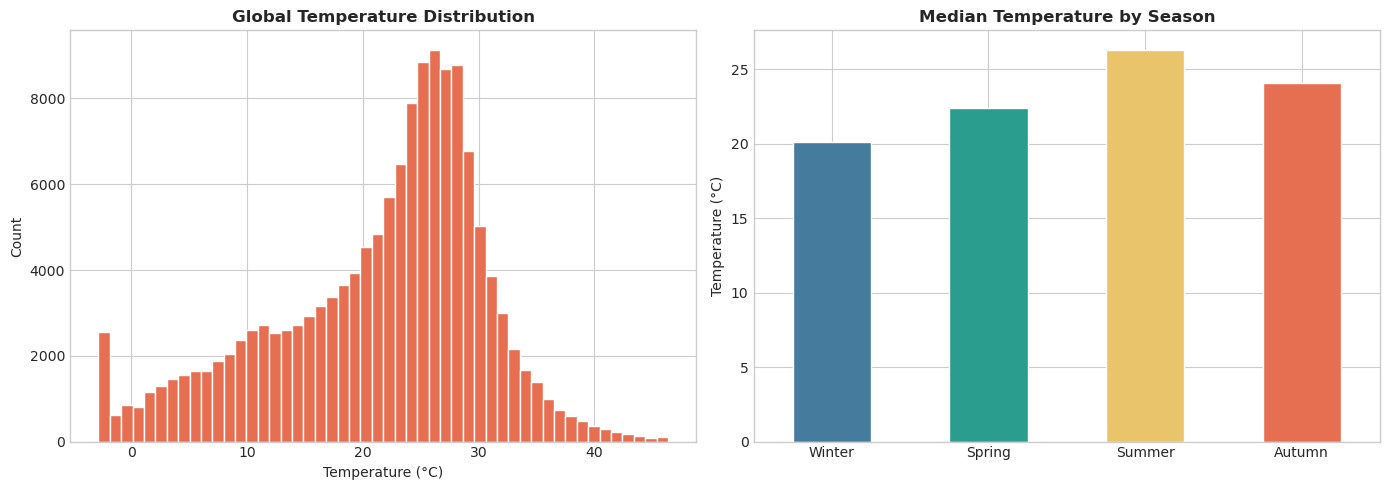

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df['temperature_celsius'].dropna(), bins=50, color='#e76f51', edgecolor='white')
axes[0].set_title('Global Temperature Distribution', fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Count')

# median temperature per season
order = ['Winter', 'Spring', 'Summer', 'Autumn']
colors = ['#457b9d', '#2a9d8f', '#e9c46a', '#e76f51']
df.groupby('season')['temperature_celsius'].median().reindex(order).plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white'
)

axes[1].set_title('Median Temperature by Season', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Temperature (°C)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / 'temperature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

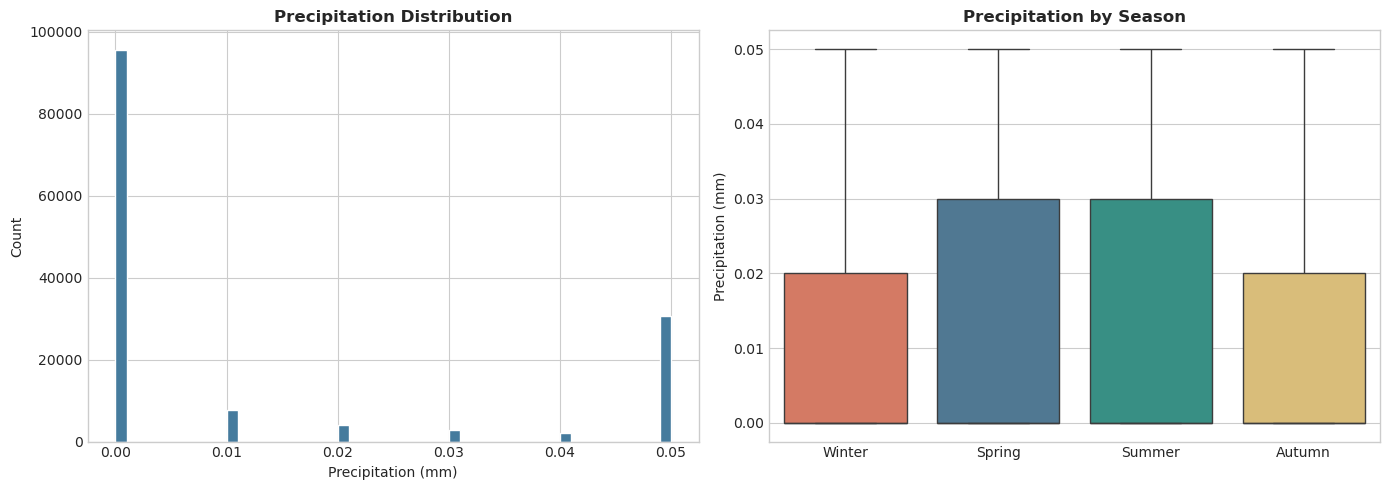

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['precip_mm'].dropna(), bins=50, color='#457b9d', edgecolor='white')
axes[0].set_title('Precipitation Distribution', fontweight='bold')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='season', y='precip_mm', order=order, hue='season', palette=colors, legend=False, ax=axes[1])
axes[1].set_title('Precipitation by Season', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Precipitation (mm)')

plt.tight_layout()
plt.savefig(FIGURES / 'precipitation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

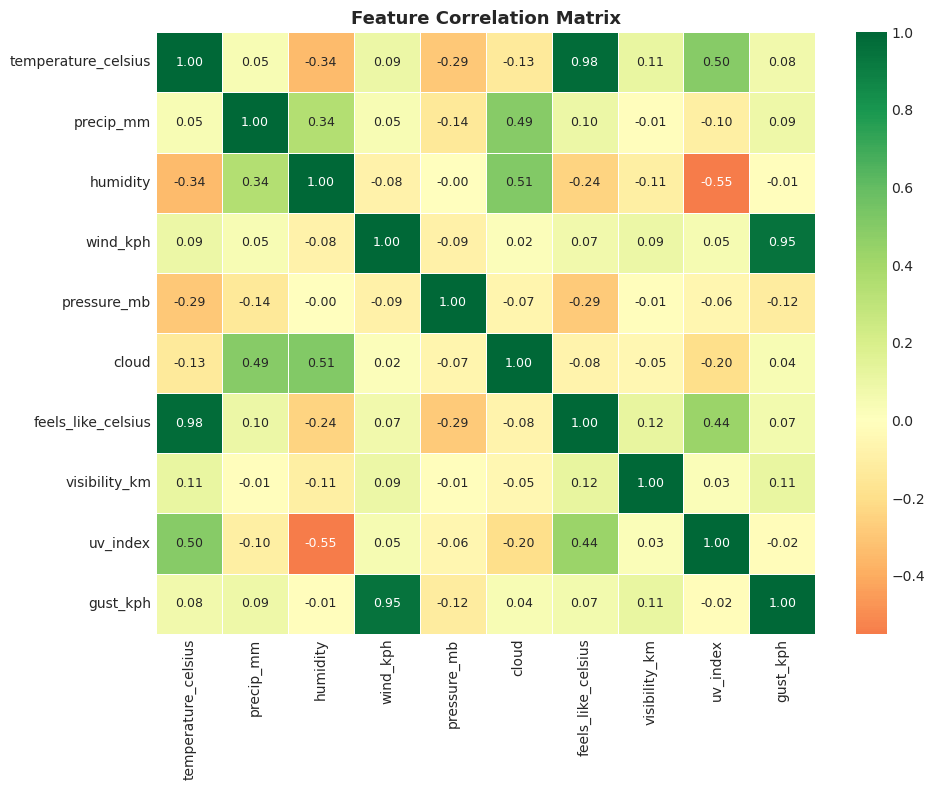

In [20]:
corr_cols = [
    'temperature_celsius', 'precip_mm', 'humidity', 'wind_kph',
    'pressure_mb', 'cloud', 'feels_like_celsius', 'visibility_km',
    'uv_index', 'gust_kph'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
           center=0, linewidths=0.4, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

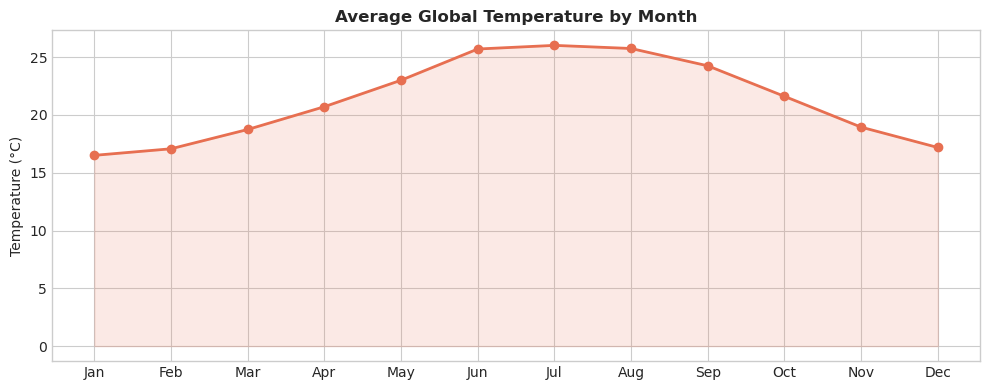

In [21]:
monthly = df.groupby('month')['temperature_celsius'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, marker='o', color='#e76f51', linewidth=2)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#e76f51')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_title('Average Global Temperature by Month', fontweight='bold')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig(FIGURES / 'monthly_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

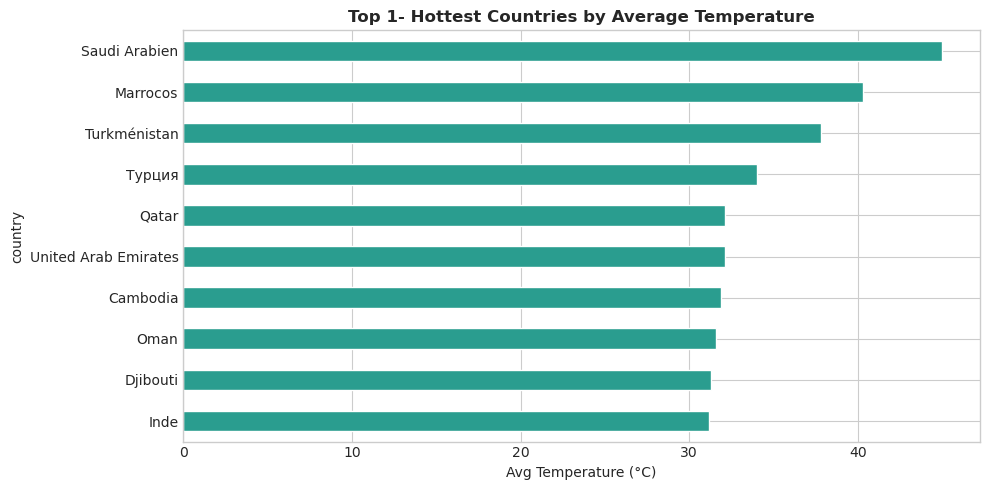

In [22]:
top_countries = (
    df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
top_countries.plot(kind='barh', ax=ax, color='#2a9d8f', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 1- Hottest Countries by Average Temperature', fontweight='bold')
ax.set_xlabel('Avg Temperature (°C)')
plt.tight_layout()
plt.savefig(FIGURES / 'top_countries_temperature.png',  dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Forecasting Model

In [24]:
ts = (
    df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean().reset_index()
)
ts.columns = ['date', 'temp']
ts['date'] = pd.to_datetime(ts['date'])
ts = ts.sort_values('date').set_index('date')
ts = ts['temp'].resample('D').mean().interpolate()

print(f'time series length: {len(ts)} days')
ts.tail()

time series length: 738 days


date
2026-05-19    21.397949
2026-05-20    21.340000
2026-05-21    21.412821
2026-05-22    21.702564
2026-05-23    22.184021
Freq: D, Name: temp, dtype: float64

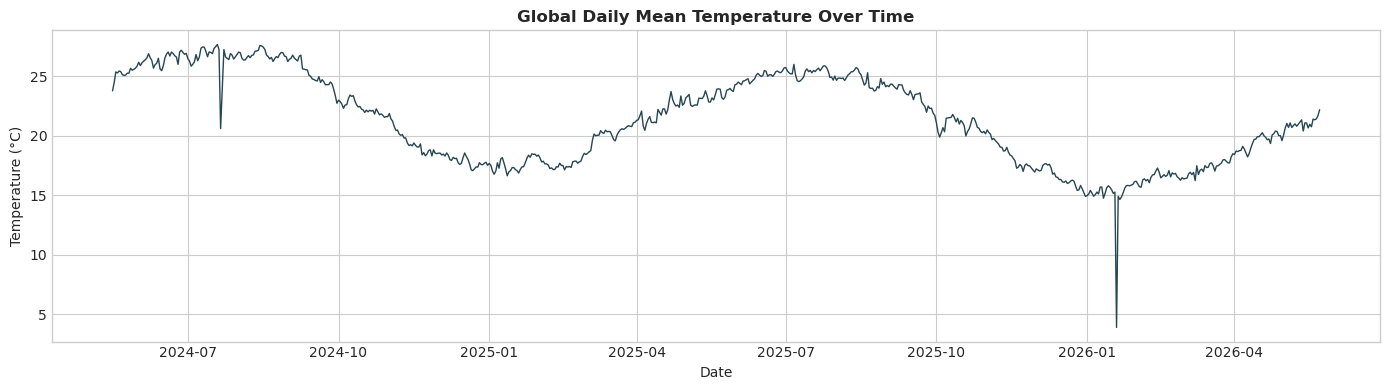

In [25]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts.values, color='#264653', linewidth=1)
ax.set_title('Global Daily Mean Temperature Over Time', fontweight='bold')
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIGURES / 'time_series.png', dpi=150, bbox_inches='tight')
plt.show()

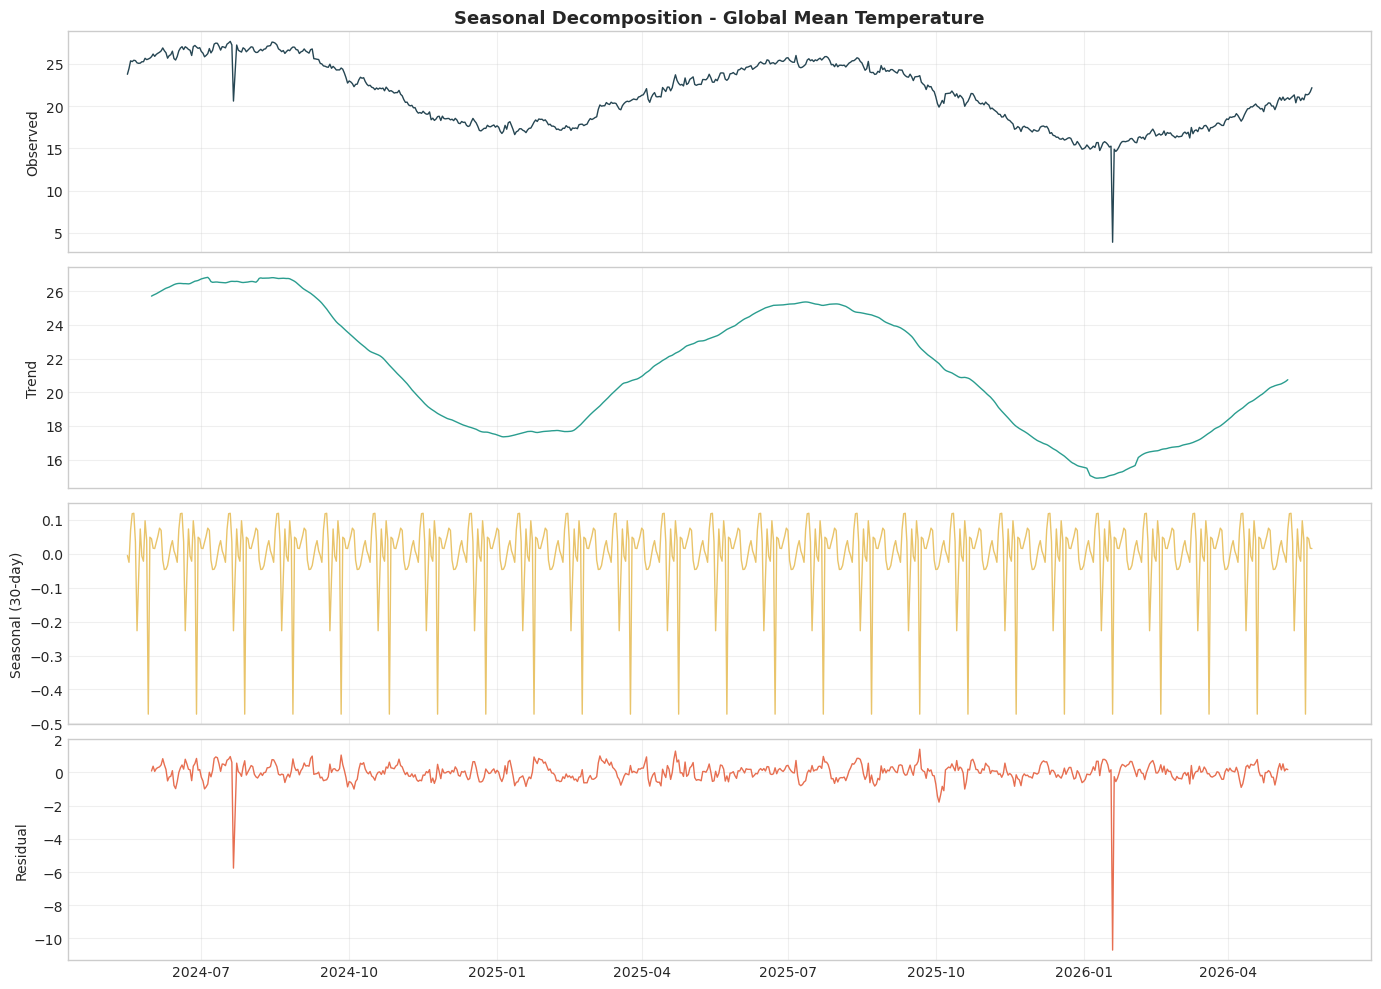

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(ts, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, component, title, color in zip(
    axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed', 'Trend', 'Seasonal (30-day)', 'Residual'],
    ['#264653', '#2a9d8f', '#e9c46a', '#e76f51']
):
    ax.plot(component, color=color, linewidth=1)
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)

axes[0].set_title('Seasonal Decomposition - Global Mean Temperature', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
HORIZON = 30

train = ts.iloc[:-HORIZON]
test = ts.iloc[-HORIZON:]

print(f'Train: {len(train)} days')
print(f'Test: {len(test)} days')

Train: 708 days
Test: 30 days


In [28]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=30
).fit(optimized=True)

print('model trained')

model trained


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forecast = model.forecast(HORIZON)
forecast.index = test.index

mae = mean_absolute_error(test, forecast)
rmse = mean_squared_error(test, forecast) ** 0.5
r2 = r2_score(test, forecast)

print('model evaluation')
print(f'MAE: {mae:.4f} °C')
print(f'RMSE: {rmse:.4f} °C')
print(f'R²: {r2:.4f}')

model evaluation
MAE: 0.5316 °C
RMSE: 0.6249 °C
R²: -0.2568


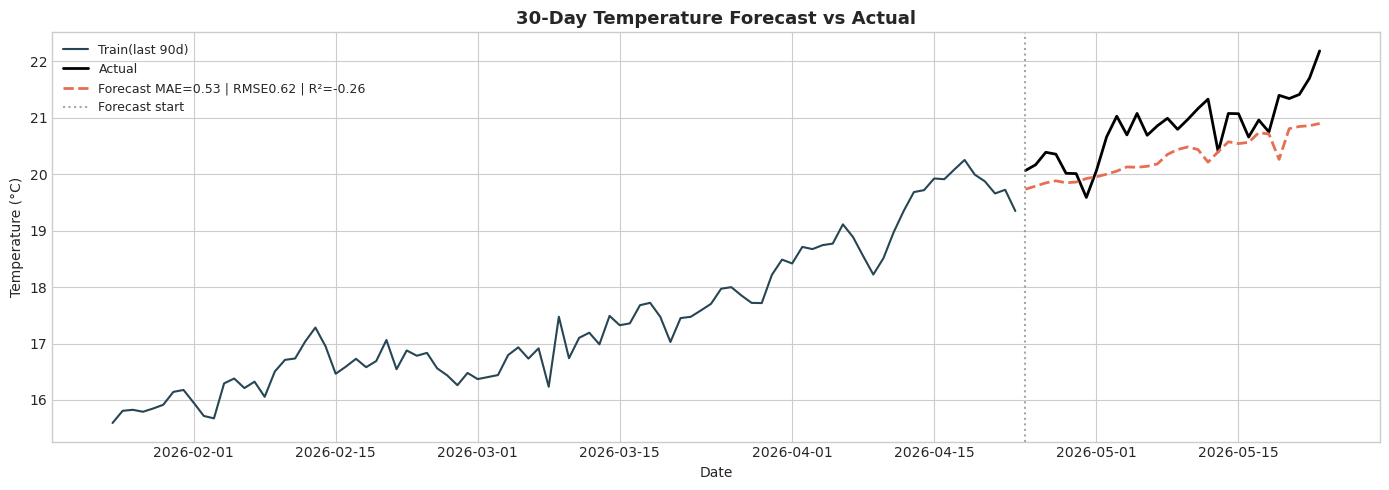

In [31]:
fig, ax =  plt.subplots(figsize=(14, 5))

ax.plot(train.index[-90:], train.iloc[-90:], color='#264653', linewidth=1.5, label='Train(last 90d)')
ax.plot(test.index, test.values, color='black', linewidth=2, label='Actual')
ax.plot(forecast.index, forecast.values, '--', color='#e76f51', linewidth=2,
       label=f'Forecast MAE={mae:.2f} | RMSE{rmse:.2f} | R²={r2:.2f}')
ax.axvline(test.index[0], color='grey', linestyle=':', alpha=0.7, label='Forecast start')

ax.set_title('30-Day Temperature Forecast vs Actual', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
import joblib

joblib.dump(model, MODELS / 'holt_winters_model.pkl')

pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [mae, rmse, r2]
}).to_csv(MODELS / 'metrics.csv', index=False)

print('model and metrics saved')

model and metrics saved
